# Objectif du notebook 

Calcul des RTFs pour une séquence passive utilisée pour la localisation basée sur l'apprentissage de variété. 

Date de création : 18/08/2026

In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from datetime import datetime

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
print(project_root)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
# img_folder = os.path.join(root_folder, "img")

c:\Users\baptiste.menetrier\Desktop\devPy\phd


In [3]:
sys.path.append(project_root)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import (
    get_dist_to_rcv, plot_gamma_along_sequence
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import (
    plot_spectro,
)

# Définition des paramètres du processeur pour l'estimation des RTFs

In [4]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 10,
    "analysis_segment_alpha_overlap": 0.95,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study
    "tau_rtf_analysis": 8.1,
    "alpha_overlap": 0.95,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

# Données communes 


In [5]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load bathy data
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

# Load wav data
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

In [6]:
def run_rtf_estimation(passive_id, start_dt, end_dt):
    # Convention for the global dataset -> passive_id + 2000
    id_event = 2000 + passive_id

    target_mmsi = None
    active_feature_args = {
        "replica_sequence_ids": [],
        "replica_pulse_slice": [],
        "load_precomputed_feature": False,
    }
    passive_feature_args = {
        "start_datetimes": [start_dt],
        "end_datetimes": [end_dt],
        "load_precomputed_feature": False,
    }

    rtf_mfp_processor.compute_event(
        active_feature_args=active_feature_args,
        passive_feature_args=passive_feature_args,
        id=id_event,
        target_mmsi=target_mmsi,
    )

In [7]:
def analyse_dr_variation(ds):
    # OBS position
    e1 = ds_gps.attrs[f"obs1_e_apriori"]
    n1 = ds_gps.attrs[f"obs1_n_apriori"]
    e2 = ds_gps.attrs[f"obs2_e_apriori"]
    n2 = ds_gps.attrs[f"obs2_n_apriori"]
    e3 = ds_gps.attrs[f"obs3_e_apriori"]
    n3 = ds_gps.attrs[f"obs3_n_apriori"]

    # Source positions
    es = ds.e_replica
    ns = ds.n_replica

    # Distance
    r1 = np.sqrt((e1 - es) ** 2 + (n1 - ns) ** 2).values
    r2 = np.sqrt((e2 - es) ** 2 + (n2 - ns) ** 2).values
    r3 = np.sqrt((e3 - es) ** 2 + (n3 - ns) ** 2).values

    dr = np.sqrt((es.values[1:] - es.values[:-1]) ** 2 + (ns.values[1:] - ns.values[:-1]) ** 2)

    # dr = np.abs(r1[1:] - r1[:-1])
    dr_med = np.median(np.abs(dr))
    dr_mean = np.mean(np.abs(dr))
    dr_std = np.std(np.abs(dr))

    print("\n")
    print("Range resolution :")
    print(f"\t median delta_r = {dr_med:.1f}m")
    print(f"\t mean delta_r = {dr_mean:.1f}m")
    print(f"\t std delta_r = {dr_std:.1f}m")

    print(f"r1 min: {r1.min()}, r1 max: {r1.max()}")
    print(f"r2 min: {r2.min()}, r2 max: {r2.max()}")
    print(f"r3 min: {r2.min()}, r3 max: {r3.max()}")

    plt.figure()
    plt.plot(ds.replica_id.values[1:], dr)
    plt.axhline(dr_med, color="k", linestyle="--")
    plt.xlabel("Replica ID")
    plt.ylabel("$\Delta r$ [m]")

In [8]:
root_event = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\event"
root_passive = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\passive"

def run_all_seq_analysis(passive_id, start_dt, end_dt, run_estimation=False):

    # # Load entire sequence
    # df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]
    # # Print usefull info
    # print_sequence_info(df_seq)

    # Run estimation if needed
    if run_estimation:
        run_rtf_estimation(passive_id, start_dt=start_dt, end_dt=end_dt)

    # Load RTF dataset
    id_event = 2000 + passive_id  # Convention for the global dataset -> seq_id + 2000
    fpath = os.path.join(root_event, f"event_{id_event}.nc")
    try:
        ds = xr.open_dataset(fpath)
        ds
    except:
        print(f"Dataset {fpath} not found !")

    # # Plot replicas positions
    # plot_seq_replica_positions(df_seq, ds_gps)
    # plot_seq_replica_positions_wgs84(df_seq, ds_gps, ds_bathy, add_transect_points=True)

    # # Plot speed of the source
    # plot_speed_along_seq(df_seq)

    # # Plot source depth
    # plot_source_depth(df_seq)

    # Analyse range resolution
    analyse_dr_variation(ds)

    # Load signal 
    fpath = os.path.join(
        root_passive,
        f"sequence_passive_{datetime.strftime(start_dt, rtf_mfp_processor.fsm_passive.datetime_fmt)}_to_{datetime.strftime(end_dt, rtf_mfp_processor.fsm_passive.datetime_fmt)}_rtf.nc",
    )
    try:
        ds_sig = xr.open_dataset(fpath)
        ds_sig
    except:
        print(f"Dataset {fpath} not found !")

    # root_fig = os.path.join(
    #     rtf_mfp_img_folder,
    #     f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
    #     )

    plot_spectro(
        ds_wav,
        t_start=start_dt,
        t_end=end_dt,
        root_fig=ds_sig.root_img,
        nperseg=2**12,
        noverlap=2**11,
        save=True,
    )

    # Plot RTF
    dist_rcv = get_dist_to_rcv(ds)
    obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
    reps = ds.replica_id.values

    plot_gamma_along_sequence(
        ds,
        dist_rcv,
        obs_cpa_idx,
        reps,
        fig_folder=ds_sig.root_img,
        # fmin=fmin,
        # fmax=fmax,
    )

# Séquence passive du 14-10-2025 à 19h55


Deriving features for active source...

Deriving replicas for passive source...

RTF processing of passive recording
RTF feature estimation...
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%Using first vessel in list (default behavior) : mmsi=228086900
A event dataset with ID 2002 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\event. This event dataset will be overwritten.
Dataset (event) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\event\event_2002.nc.


Range resolution :
	 median delta_r = 1.7m
	 mean delta_r = 2.3m
	 std delta_r = 0.8m
r1 min: 1204.732177734375, r1 max: 1564.495849609375
r2 min: 331.7824401855469, r2 max: 680.4998779296875
r3 min: 331.7824401855469, r3 max: 648.2064208984375
	Plotting spectrograms ...


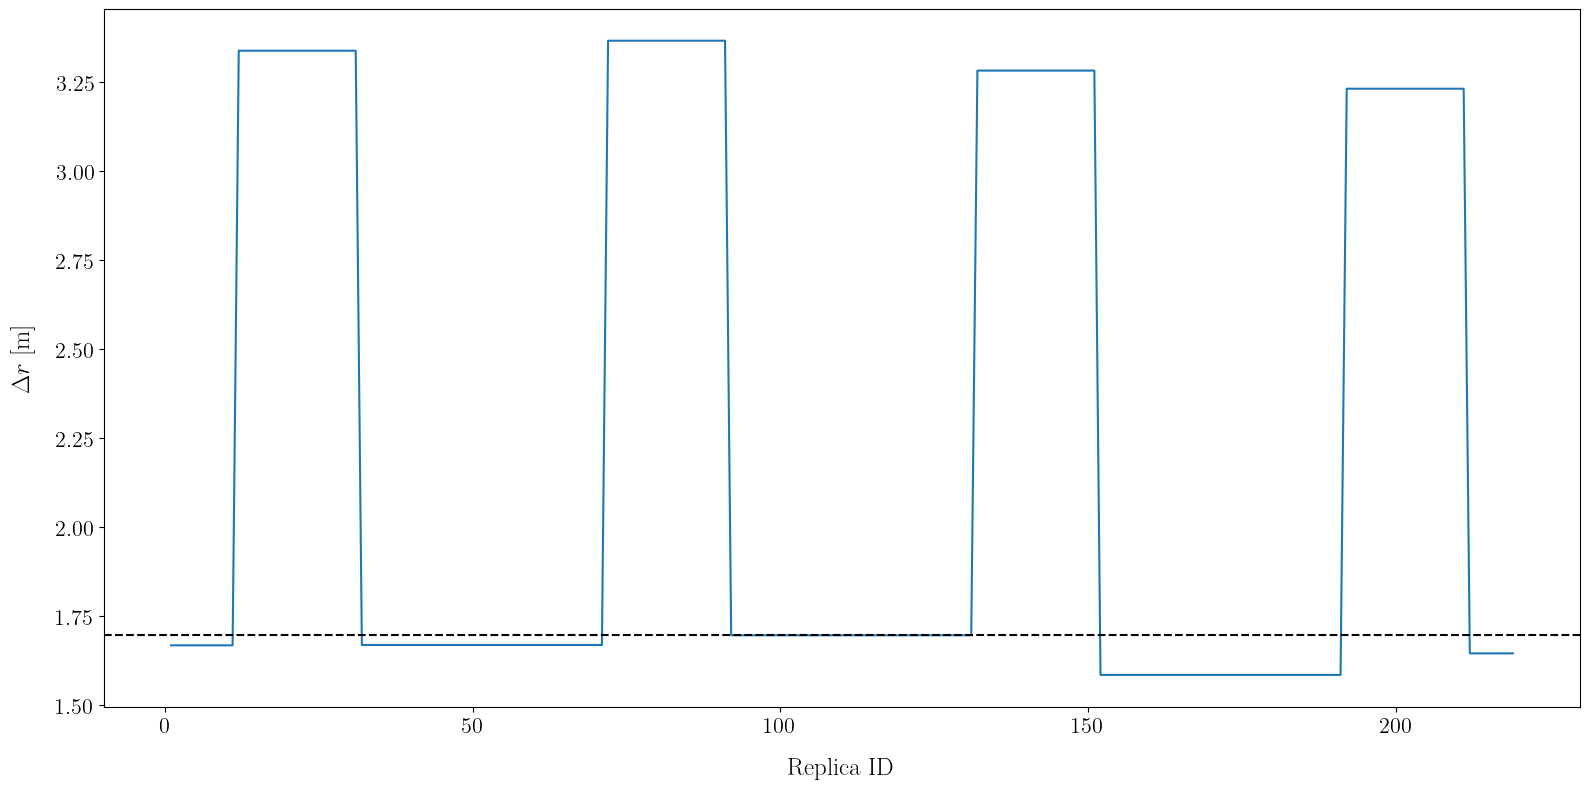

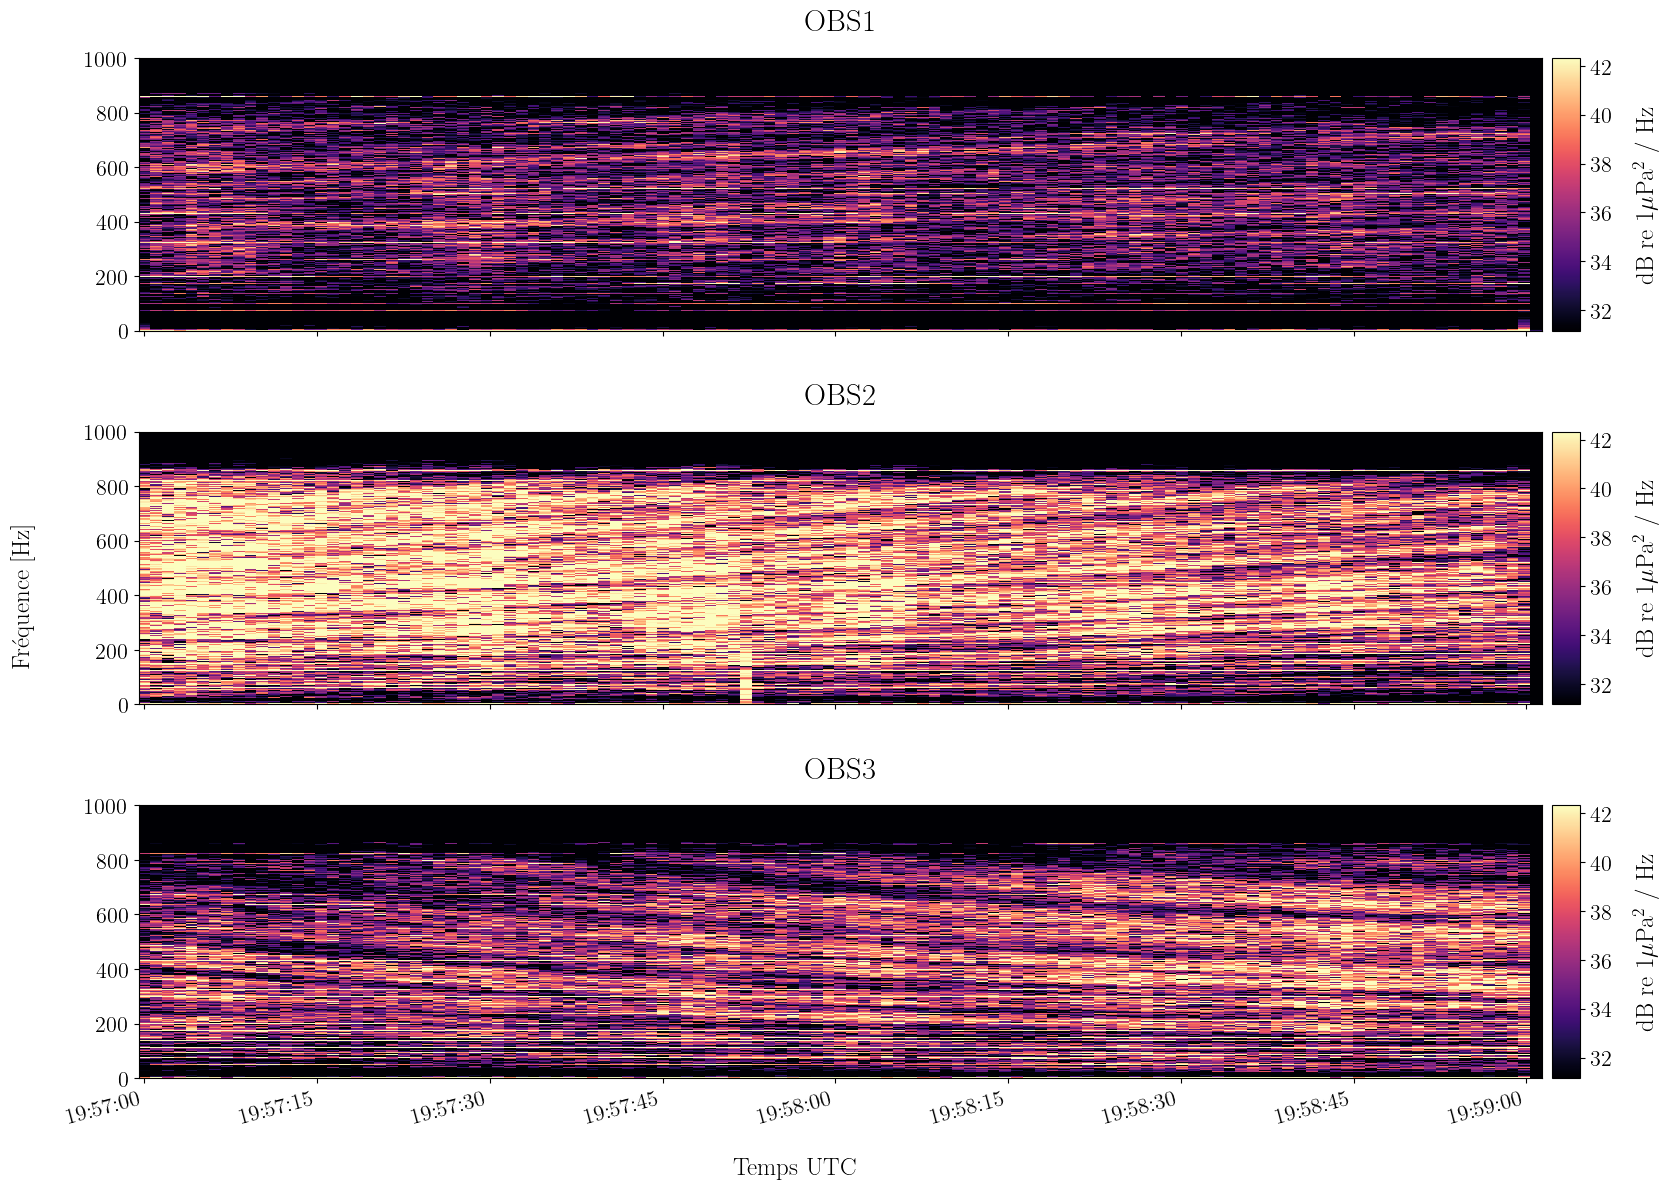

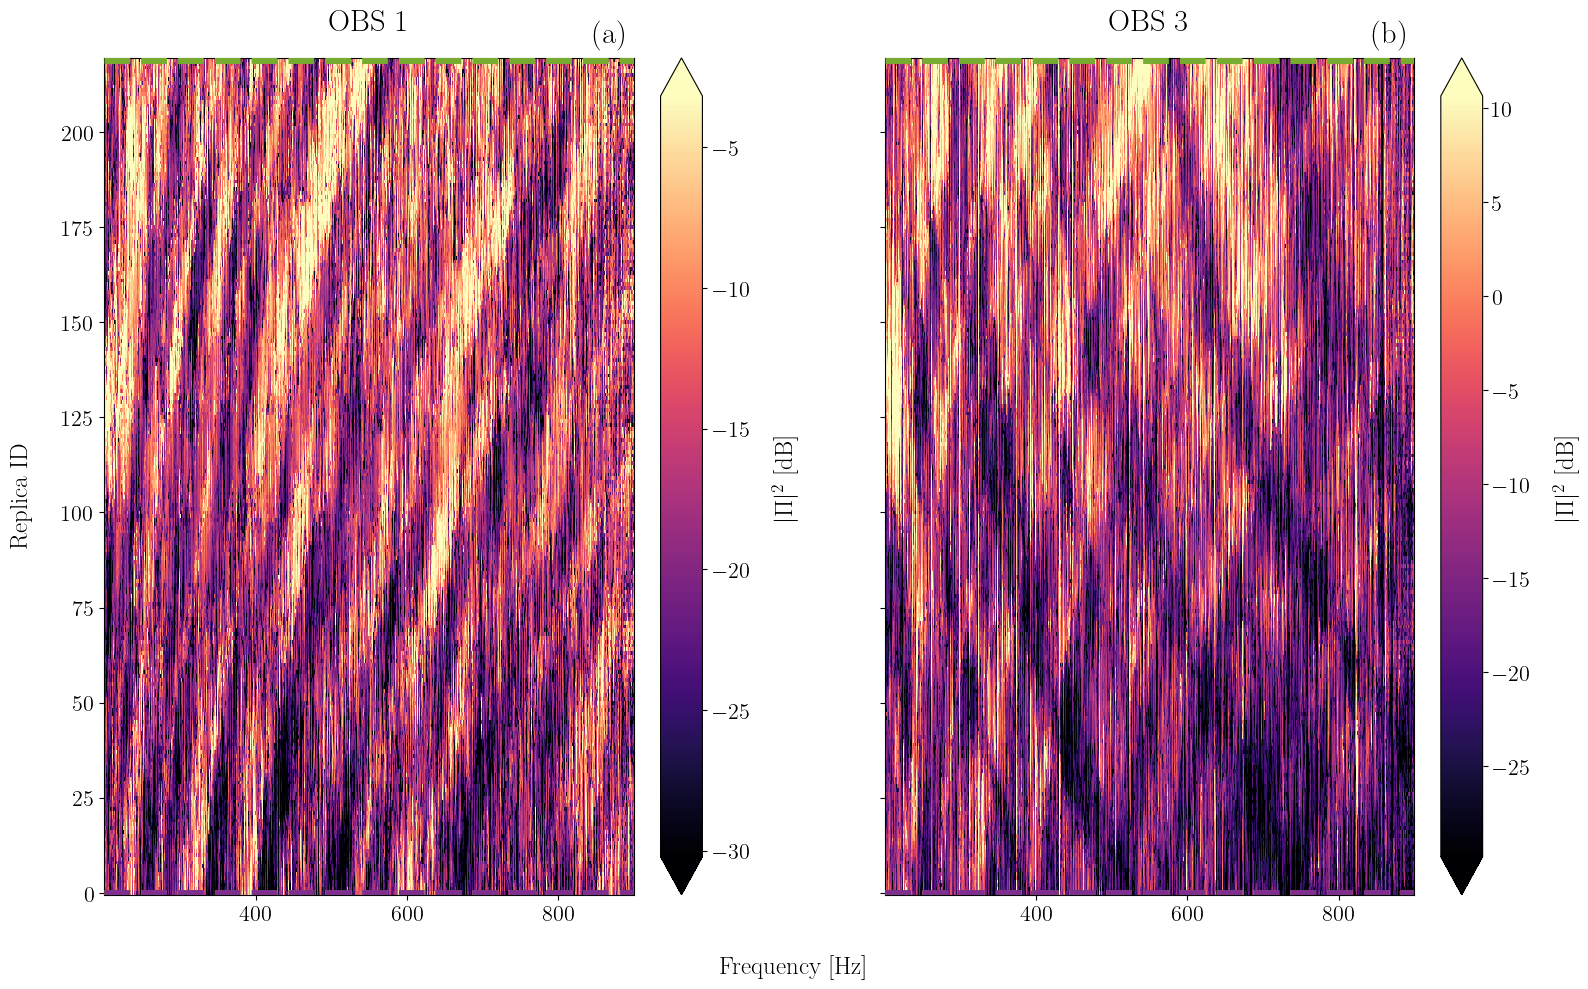

In [9]:
# start_datetime = datetime(year=2025, month=10, day=14, hour=19, minute=55, second=0)
# end_datetime = datetime(year=2025, month=10, day=14, hour=20, minute=5, second=0)
# passive_id = 1

start_datetime = datetime(year=2025, month=10, day=14, hour=19, minute=57, second=00)
end_datetime = datetime(year=2025, month=10, day=14, hour=19, minute=59, second=0)
passive_id = 2

# start_datetime = datetime(year=2025, month=10, day=14, hour=19, minute=57, second=15)
# end_datetime = datetime(year=2025, month=10, day=14, hour=19, minute=58, second=0)
# passive_id = 3
run_all_seq_analysis(passive_id=passive_id, start_dt=start_datetime, end_dt=end_datetime, run_estimation=True)